# Phase 4 Benchmark: Baseline vs Exogenous with New Text/Event Features (`t5yie_diff1`)

Benchmark contract:
- this notebook is the ground-truth source for deciding the next Phase 4 model-pipeline update,
- scope is notebook-only in this pass,
- evaluation is leakage-safe expanding one-step walk-forward,
- promotion rule is fixed at >= 2% gain on both RMSE and MAE (test, paired timestamps).


## Setup and Data Load

Data sources:
- `data/targets/model_dataset_t5yie.parquet`
- `data/splits/time_splits.json`

Implementation policy:
- reuse production helpers:
  - `models.evaluation.walk_forward.run_expanding_one_step_sarimax`
  - `models.evaluation.metrics.compute_metrics`
- fail fast if required columns are missing, with rebuild guidance.


In [4]:
from __future__ import annotations

import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
from __future__ import annotations

import warnings
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from current working directory.")


repo_root = find_repo_root(Path.cwd())
sys.path.insert(0, str(repo_root))

from models.evaluation.metrics import compute_metrics
from models.evaluation.walk_forward import run_expanding_one_step_sarimax

sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 200

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from current working directory.")


repo_root = find_repo_root(Path.cwd())
dataset_path = repo_root / "data" / "targets" / "model_dataset_t5yie.parquet"
splits_path = repo_root / "data" / "splits" / "time_splits.json"

if not dataset_path.exists():
    raise FileNotFoundError(f"Missing dataset parquet: {dataset_path}")
if not splits_path.exists():
    raise FileNotFoundError(f"Missing split artifact json: {splits_path}")

print(f"repo_root: {repo_root}")
print(f"dataset_path: {dataset_path}")
print(f"splits_path: {splits_path}")
from models.evaluation.walk_forward import run_expanding_one_step_sarimax

sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 200

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from current working directory.")


repo_root = find_repo_root(Path.cwd())
dataset_path = repo_root / "data" / "targets" / "model_dataset_t5yie.parquet"
splits_path = repo_root / "data" / "splits" / "time_splits.json"

if not dataset_path.exists():
    raise FileNotFoundError(f"Missing dataset parquet: {dataset_path}")
if not splits_path.exists():
    raise FileNotFoundError(f"Missing split artifact json: {splits_path}")

print(f"repo_root: {repo_root}")
print(f"dataset_path: {dataset_path}")
print(f"splits_path: {splits_path}")


repo_root: c:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting
dataset_path: c:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\targets\model_dataset_t5yie.parquet
splits_path: c:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\splits\time_splits.json
repo_root: c:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting
dataset_path: c:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\targets\model_dataset_t5yie.parquet
splits_path: c:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\splits\time_splits.json


In [6]:
TARGET_COL = "t5yie_diff1"
DATE_COL = "date"

MODEL_VARIANTS = {
    "baseline_univariate": [],
    "exog_minimal_counts": ["hawkish_score", "novelty", "doc_count"],
    "exog_share_variant": ["hawkish_score", "novelty", "hawkish_share", "dovish_share"],
    "exog_text_event_variant": [
        "hawkish_score",
        "novelty",
        "doc_count",
        "text_length_words_max",
        "hawkish_score_max_abs_signed_7d",
        "hawkish_score_max_abs_signed_14d",
        "hawkish_score_max_abs_signed_30d",
    ],
    "exog_text_event_role_variant": [
        "hawkish_score",
        "novelty",
        "doc_count",
        "text_length_words_max",
        "hawkish_score_max_abs_signed_7d",
        "hawkish_score_max_abs_signed_14d",
        "hawkish_score_max_abs_signed_30d",
        "role_share_chairman",
    ],
}

benchmark_df = pd.read_parquet(dataset_path).copy()
benchmark_df[DATE_COL] = pd.to_datetime(benchmark_df[DATE_COL], errors="coerce").dt.normalize()
benchmark_df = benchmark_df.dropna(subset=[DATE_COL]).sort_values(DATE_COL, kind="mergesort").reset_index(drop=True)

assert benchmark_df[DATE_COL].is_monotonic_increasing, "Dataset date index must be monotonic increasing."
assert benchmark_df[DATE_COL].is_unique, "Dataset date index must be unique."

required_base = {DATE_COL, TARGET_COL, "n_hawkish", "n_dovish", "n_target_sentences"}
required_variant = {
    col
    for variant_cols in MODEL_VARIANTS.values()
    for col in variant_cols
    if col not in {"hawkish_share", "dovish_share"}
}
required_columns = required_base | required_variant
missing = sorted(required_columns.difference(benchmark_df.columns))
if missing:
    raise ValueError(
        "Dataset is missing required columns for this benchmark: "
        f"{missing}. Rebuild with: python -m datasets.build_dataset.builder"
    )

benchmark_df["hawkish_share"] = np.where(
    benchmark_df["n_target_sentences"] > 0,
    benchmark_df["n_hawkish"] / benchmark_df["n_target_sentences"],
    np.nan,
)
benchmark_df["dovish_share"] = np.where(
    benchmark_df["n_target_sentences"] > 0,
    benchmark_df["n_dovish"] / benchmark_df["n_target_sentences"],
    np.nan,
)

with splits_path.open("r", encoding="utf-8") as f:
    split_payload = json.load(f)

boundaries = split_payload.get("boundaries", {})
for key in ["val_start", "val_end", "test_start"]:
    if key not in boundaries:
        raise ValueError(f"Split artifact missing boundary: {key!r}")

SPLITS = {
    "val": (
        pd.Timestamp(boundaries["val_start"]).normalize(),
        pd.Timestamp(boundaries["val_end"]).normalize(),
    ),
    "test": (
        pd.Timestamp(boundaries["test_start"]).normalize(),
        pd.Timestamp(boundaries["test_end"]).normalize() if boundaries.get("test_end") else None,
    ),
}

print("Split boundaries used:")
for split_name, (start, end) in SPLITS.items():
    print(f"- {split_name}: start={start.date() if start is not None else None}, end={end.date() if end is not None else None}")

print(f"Model variants:")
for name, cols in MODEL_VARIANTS.items():
    print(f"- {name}: {cols if cols else '[univariate]'}")

display(benchmark_df.head(5))


Split boundaries used:
- val: start=2017-01-01, end=2020-12-31
- test: start=2021-01-01, end=None
Model variants:
- baseline_univariate: [univariate]
- exog_minimal_counts: ['hawkish_score', 'novelty', 'doc_count']
- exog_share_variant: ['hawkish_score', 'novelty', 'hawkish_share', 'dovish_share']
- exog_text_event_variant: ['hawkish_score', 'novelty', 'doc_count', 'text_length_words_max', 'hawkish_score_max_abs_signed_7d', 'hawkish_score_max_abs_signed_14d', 'hawkish_score_max_abs_signed_30d']
- exog_text_event_role_variant: ['hawkish_score', 'novelty', 'doc_count', 'text_length_words_max', 'hawkish_score_max_abs_signed_7d', 'hawkish_score_max_abs_signed_14d', 'hawkish_score_max_abs_signed_30d', 'role_share_chairman']


,target_month,date,feature_month_used,t5yie_diff1,t5yie_diff1_abs_mean,t5yie_obs,hawkish_score,novelty,n_hawkish,n_dovish,n_neutral,n_target_sentences,doc_count,text_length_words_max,role_share_chairman,hawkish_score_max_abs_signed_7d,hawkish_score_max_abs_signed_14d,hawkish_score_max_abs_signed_30d,missing_period_reason,hawkish_share,dovish_share
0,2003-01,2003-01-01,2002-12,0.009500,0.035500,20,0.0,0.113067,0.0,0.0,1.0,1.0,1.0,476.0,NaN,NaN,NaN,0.0,residual_true_gap,0.0,0.0
1,2003-02,2003-02-01,2003-01,0.013684,0.033684,19,0.0,0.204370,0.0,0.0,1.0,1.0,1.0,475.0,NaN,0.0,0.0,0.0,residual_true_gap,0.0,0.0
2,2003-03,2003-03-01,2003-02,-0.004762,0.052381,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_docs_month,NaN,NaN
3,2003-04,2003-04-01,2003-03,-0.009524,0.028571,21,0.0,0.144288,0.0,0.0,1.0,1.0,1.0,532.0,NaN,NaN,0.0,0.0,residual_true_gap,0.0,0.0
4,2003-05,2003-05-01,2003-04,-0.009048,0.050000,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_docs_month,NaN,NaN


## Feature Sets and Split Policy

- Variant map is fixed for this benchmark.
- Split boundaries come from `data/splits/time_splits.json`.
- Benchmark runs on `val` and `test` only.


In [7]:
corr_cols = [
    "hawkish_score",
    "novelty",
    "doc_count",
    "text_length_words_max",
    "role_share_chairman",
    "hawkish_score_max_abs_signed_7d",
    "hawkish_score_max_abs_signed_14d",
    "hawkish_score_max_abs_signed_30d",
]
display(benchmark_df[corr_cols].corr(numeric_only=True))


,hawkish_score,novelty,doc_count,text_length_words_max,role_share_chairman,hawkish_score_max_abs_signed_7d,hawkish_score_max_abs_signed_14d,hawkish_score_max_abs_signed_30d
hawkish_score,1.000000,0.032851,0.126586,-0.146834,-0.157645,0.700588,0.704565,0.730265
novelty,0.032851,1.000000,0.224763,0.137712,0.121267,-0.037035,-0.090072,0.037243
doc_count,0.126586,0.224763,1.000000,0.281558,-0.159184,0.192537,0.172298,0.234891
text_length_words_max,-0.146834,0.137712,0.281558,1.000000,-0.064298,-0.253718,-0.187904,-0.109077
role_share_chairman,-0.157645,0.121267,-0.159184,-0.064298,1.000000,-0.182623,-0.220460,-0.108422
hawkish_score_max_abs_signed_7d,0.700588,-0.037035,0.192537,-0.253718,-0.182623,1.000000,0.836178,0.690157
hawkish_score_max_abs_signed_14d,0.704565,-0.090072,0.172298,-0.187904,-0.220460,0.836178,1.000000,0.786856
hawkish_score_max_abs_signed_30d,0.730265,0.037243,0.234891,-0.109077,-0.108422,0.690157,0.786856,1.000000


## Walk-Forward Benchmark Run

Using production walk-forward helper (`run_expanding_one_step_sarimax`) with:
- order `(1, 0, 0)`
- trend `'c'`
- expanding one-step forecasting
- minimum train observations = 36


In [8]:
model_order = (1, 0, 0)
model_trend = "c"
min_train_obs = 36

all_predictions: dict[tuple[str, str], pd.DataFrame] = {}
rows = []

for variant_name, exog_cols in MODEL_VARIANTS.items():
    for split_name in ["val", "test"]:
        split_start, split_end = SPLITS[split_name]

        pred_df, n_fail = run_expanding_one_step_sarimax(
            df=benchmark_df,
            target_col=TARGET_COL,
            date_col=DATE_COL,
            eval_start=split_start,
            eval_end=split_end,
            exog_cols=exog_cols,
            order=model_order,
            trend=model_trend,
            min_train_obs=min_train_obs,
        )

        if not pred_df.empty:
            assert pred_df["date"].is_monotonic_increasing
            if split_start is not None:
                assert (pred_df["date"] >= split_start).all()
            if split_end is not None:
                assert (pred_df["date"] <= split_end).all()

        metrics = compute_metrics(pred_df, "actual", "pred")
        rows.append(
            {
                "model_variant": variant_name,
                "split": split_name,
                "rmse": metrics["rmse"],
                "mae": metrics["mae"],
                "directional_accuracy": metrics["directional_accuracy"],
                "n_forecasts": metrics["n_forecasts"],
                "n_fit_failures": int(n_fail),
                "exog_cols": ", ".join(exog_cols) if exog_cols else "[none]",
            }
        )
        all_predictions[(variant_name, split_name)] = pred_df

results_table = pd.DataFrame(rows).sort_values(["split", "rmse", "mae"], na_position="last").reset_index(drop=True)

expected_rows = len(MODEL_VARIANTS) * 2
assert len(results_table) == expected_rows, f"Expected {expected_rows} rows in results_table, got {len(results_table)}"

compact_results = results_table[["split", "model_variant", "rmse", "mae", "directional_accuracy", "n_forecasts"]]
display(compact_results)


,split,model_variant,rmse,mae,directional_accuracy,n_forecasts
0,test,exog_text_event_role_variant,0.009144,0.006942,0.454545,44
1,test,exog_text_event_variant,0.009271,0.007060,0.488889,45
2,test,exog_share_variant,0.009391,0.007278,0.444444,63
3,test,baseline_univariate,0.009405,0.007277,0.444444,63
4,test,exog_minimal_counts,0.009422,0.007235,0.476190,63
5,val,exog_minimal_counts,0.008756,0.006709,0.437500,48
6,val,baseline_univariate,0.008928,0.006762,0.437500,48
7,val,exog_share_variant,0.008986,0.006932,0.404255,47
8,val,exog_text_event_variant,0.009664,0.006853,0.656250,32
9,val,exog_text_event_role_variant,0.009884,0.006906,0.562500,32


## Paired Fair Comparison

Each exogenous variant is compared to baseline on matched timestamps within each split.


In [9]:
baseline_variant = "baseline_univariate"
exog_variants = sorted([name for name in MODEL_VARIANTS if name != baseline_variant])

paired_rows = []
for exog_variant in exog_variants:
    for split_name in ["val", "test"]:
        base_pred = all_predictions[(baseline_variant, split_name)]
        exog_pred = all_predictions[(exog_variant, split_name)]

        common_dates = sorted(set(base_pred["date"]) & set(exog_pred["date"]))
        if not common_dates:
            paired_rows.append(
                {
                    "split": split_name,
                    "exog_variant": exog_variant,
                    "n_common_dates": 0,
                    "baseline_rmse": np.nan,
                    "exog_rmse": np.nan,
                    "rmse_improvement_pct": np.nan,
                    "baseline_mae": np.nan,
                    "exog_mae": np.nan,
                    "mae_improvement_pct": np.nan,
                }
            )
            continue

        b = base_pred[base_pred["date"].isin(common_dates)].sort_values("date").reset_index(drop=True)
        e = exog_pred[exog_pred["date"].isin(common_dates)].sort_values("date").reset_index(drop=True)
        assert (b["date"].values == e["date"].values).all(), "Timestamp mismatch in paired comparison."

        b_m = compute_metrics(b, "actual", "pred")
        e_m = compute_metrics(e, "actual", "pred")

        b_rmse = float(b_m["rmse"])
        e_rmse = float(e_m["rmse"])
        b_mae = float(b_m["mae"])
        e_mae = float(e_m["mae"])

        paired_rows.append(
            {
                "split": split_name,
                "exog_variant": exog_variant,
                "n_common_dates": len(common_dates),
                "baseline_rmse": b_rmse,
                "exog_rmse": e_rmse,
                "rmse_improvement_pct": 100.0 * (b_rmse - e_rmse) / b_rmse if b_rmse else np.nan,
                "baseline_mae": b_mae,
                "exog_mae": e_mae,
                "mae_improvement_pct": 100.0 * (b_mae - e_mae) / b_mae if b_mae else np.nan,
            }
        )

paired_comparison = pd.DataFrame(paired_rows).sort_values(["split", "exog_variant"]).reset_index(drop=True)

expected_paired_rows = len(exog_variants) * 2
assert len(paired_comparison) == expected_paired_rows, (
    f"Expected {expected_paired_rows} rows in paired_comparison, got {len(paired_comparison)}"
)

display(paired_comparison)


,split,exog_variant,n_common_dates,baseline_rmse,exog_rmse,rmse_improvement_pct,baseline_mae,exog_mae,mae_improvement_pct
0,test,exog_minimal_counts,63,0.009405,0.009422,-0.187661,0.007277,0.007235,0.567820
1,test,exog_share_variant,63,0.009405,0.009391,0.139303,0.007277,0.007278,-0.013083
2,test,exog_text_event_role_variant,44,0.009086,0.009144,-0.643404,0.006743,0.006942,-2.947930
3,test,exog_text_event_variant,45,0.009281,0.009271,0.113596,0.006941,0.007060,-1.728551
4,val,exog_minimal_counts,48,0.008928,0.008756,1.922712,0.006762,0.006709,0.783597
5,val,exog_share_variant,47,0.009023,0.008986,0.399918,0.006900,0.006932,-0.457331
6,val,exog_text_event_role_variant,32,0.008907,0.009884,-10.968194,0.006537,0.006906,-5.648938
7,val,exog_text_event_variant,32,0.008907,0.009664,-8.500343,0.006537,0.006853,-4.837165


## Test-Period Plot

Plot baseline vs best exogenous variant on matched test timestamps.


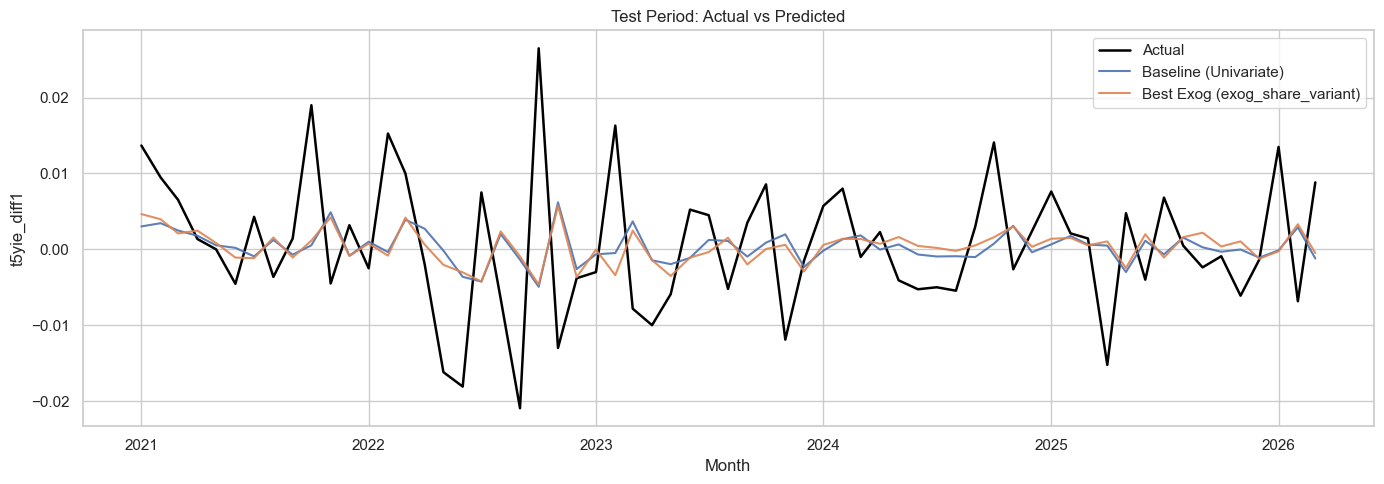

,date,actual,baseline_pred,best_exog_pred
0,2021-01-01,0.013684,0.003018,0.004647
1,2021-02-01,0.009474,0.003447,0.003964
2,2021-03-01,0.006522,0.002482,0.002091
3,2021-04-01,0.001364,0.001790,0.002471
4,2021-05-01,0.000000,0.000531,0.000837
5,2021-06-01,-0.004545,0.000197,-0.001091
6,2021-07-01,0.004286,-0.000932,-0.001168
7,2021-08-01,-0.003636,0.001240,0.001554
8,2021-09-01,0.001429,-0.000704,-0.001085
9,2021-10-01,0.019000,0.000533,0.001154


In [10]:
paired_test = paired_comparison[paired_comparison["split"] == "test"].copy()
if paired_test.empty:
    raise ValueError("No test paired-comparison rows available.")

best_paired = paired_test.sort_values(
    ["rmse_improvement_pct", "mae_improvement_pct"],
    ascending=False,
    na_position="last",
).iloc[0]
best_variant = str(best_paired["exog_variant"])

baseline_test = all_predictions[(baseline_variant, "test")].copy()
best_exog_test = all_predictions[(best_variant, "test")].copy()

common_test_dates = sorted(set(baseline_test["date"]) & set(best_exog_test["date"]))
plot_base = baseline_test[baseline_test["date"].isin(common_test_dates)].sort_values("date").reset_index(drop=True)
plot_exog = best_exog_test[best_exog_test["date"].isin(common_test_dates)].sort_values("date").reset_index(drop=True)

if not plot_base.empty and not plot_exog.empty:
    assert (plot_base["date"].values == plot_exog["date"].values).all(), "Plot timestamps mismatch."

plot_df = pd.DataFrame(
    {
        "date": plot_base["date"],
        "actual": plot_base["actual"],
        "baseline_pred": plot_base["pred"],
        "best_exog_pred": plot_exog["pred"],
    }
)

plt.figure(figsize=(14, 5))
if not plot_df.empty:
    plt.plot(plot_df["date"], plot_df["actual"], label="Actual", linewidth=1.8, color="black")
    plt.plot(plot_df["date"], plot_df["baseline_pred"], label="Baseline (Univariate)", alpha=0.9)
    plt.plot(plot_df["date"], plot_df["best_exog_pred"], label=f"Best Exog ({best_variant})", alpha=0.9)
plt.title("Test Period: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("t5yie_diff1")
plt.legend()
plt.tight_layout()
plt.show()

display(plot_df.head(10))


## Decision and Recommendation

Locked decision rule:
- promote only if test RMSE gain >= 2% and test MAE gain >= 2% on paired timestamps.


In [11]:
meaningful_threshold_pct = 2.0

rmse_gain = float(best_paired["rmse_improvement_pct"])
mae_gain = float(best_paired["mae_improvement_pct"])
is_meaningful = (rmse_gain >= meaningful_threshold_pct) and (mae_gain >= meaningful_threshold_pct)

if is_meaningful:
    recommendation = (
        f"Promote {best_variant}: test RMSE gain {rmse_gain:.2f}%, "
        f"test MAE gain {mae_gain:.2f}% (>= {meaningful_threshold_pct:.1f}% both)."
    )
    pipeline_action = f"Use baseline + {best_variant} as primary exogenous benchmark in next pipeline update."
else:
    recommendation = (
        f"Do not promote yet: best variant {best_variant} has RMSE gain {rmse_gain:.2f}% "
        f"and MAE gain {mae_gain:.2f}%, below the >= {meaningful_threshold_pct:.1f}% dual-gain rule."
    )
    pipeline_action = "Keep univariate baseline default; keep exogenous variants as diagnostic benchmarks."

print("Best exogenous variant (test paired):", best_variant)
print("RMSE improvement (%):", rmse_gain)
print("MAE improvement (%):", mae_gain)
print("Meets promotion threshold:", bool(is_meaningful))
print()
print("Recommendation:")
print(recommendation)
print()
print("Pipeline action for follow-up implementation:")
print(pipeline_action)


Best exogenous variant (test paired): exog_share_variant
RMSE improvement (%): 0.13930320950242553
MAE improvement (%): -0.013082962935177661
Meets promotion threshold: False

Recommendation:
Do not promote yet: best variant exog_share_variant has RMSE gain 0.14% and MAE gain -0.01%, below the >= 2.0% dual-gain rule.

Pipeline action for follow-up implementation:
Keep univariate baseline default; keep exogenous variants as diagnostic benchmarks.


## Reproducibility and Integrity Checks

These checks enforce the benchmark contract before any downstream pipeline mutation is considered.


In [12]:
assert benchmark_df[DATE_COL].is_monotonic_increasing
assert benchmark_df[DATE_COL].is_unique

for required_col in required_columns:
    assert required_col in benchmark_df.columns, f"Missing required benchmark column: {required_col}"

assert set(results_table["model_variant"].unique()) == set(MODEL_VARIANTS.keys())
assert set(paired_comparison["exog_variant"].unique()) == set(exog_variants)

for (variant, split_name), pred in all_predictions.items():
    if pred.empty:
        continue
    assert pred["date"].is_monotonic_increasing, f"Prediction dates not monotonic for {variant}/{split_name}"
    split_start, split_end = SPLITS[split_name]
    if split_start is not None:
        assert (pred["date"] >= split_start).all(), f"Prediction date before split start for {variant}/{split_name}"
    if split_end is not None:
        assert (pred["date"] <= split_end).all(), f"Prediction date after split end for {variant}/{split_name}"

assert len(results_table) == len(MODEL_VARIANTS) * 2
assert len(paired_comparison) == len(exog_variants) * 2

print("Core integrity checks passed.")
print("Notebook is deterministic with stable inputs and fixed variant definitions.")
print("This notebook is the source of truth for the next model-pipeline update decision.")


Core integrity checks passed.
Notebook is deterministic with stable inputs and fixed variant definitions.
This notebook is the source of truth for the next model-pipeline update decision.
